# Simplest use case

## Running a model from the config file

Setting up the `dolphin` ecosystem:

- Install `dolphin`, `lenstronomy`, and the required dependencies.
- Create an input/output directory for `dolphin`, we are using "../io_directory_example" in this example.
- Set up these directories inside the input/output directory. Look inside "../io_directory_example" for example. 
    - **data**: contains subdirectories for each lens system with a data and PSF files for each band.
    - **settings**: contains the 'config_{lens_name}.yaml' files for each lens system,
        - **masks**: contains the custom 'mask_{lens_name}_{band}.npy' files (optional),
    - **logs**: to write the log files from model runs,
    - **outputs**: to save the model outputs,
    - **hpc**: *optional*, contains scripts to submit batch jobs in MPI.
 

   
### Data format

The image data file needs to be in the hdf5 format with the following datasets:

- `image_data`: reduced and background subtracted image cutout centered at the lens system,
- `background_rms`: background level,
- `exposure_time`: the map of exposure times for each pixel, so that `image_data * exposure_time` is Poisson noise distributed,
- `ra_at_xy_0`: RA of the (0, 0) pixel in the `image_data` cutout,
- `dec_at_xy_0`: Dec of the (0, 0) pixel in the `image_data` cutout,
- `transform_pix2angle`: a transform matrix to map the pixel numbers (x, y) to angles (RA, Dec).

The PSF data file needs to be in the hdf5 format with the following datasets:

- `kernel_point_source`: a pixelated PSF (not required to have the same dimension of `image_data`),
- `psf_variance_map`: *optional*, uncertainty in the provided PSF, needs to have the same dimension of `kernel_point_source`. 

### Config file format

The 'config_{lens_name}.yaml' file provides you options to set up the lens model. Here is the content of the config file that is used in the example model below.

### Imports

In [1]:
import os
os.nice(19)

for _var in (
    "OPENBLAS_NUM_THREADS",
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(_var, "1")

from dolphin.processor import Processor
from dolphin.analysis.output import Output

import multiprocessing

### create a `Processor` instance and point to the IO directory

In [2]:
processor = Processor("../io_directory_example/")

### Run a model by calling the  `swim()` method

In [3]:
# processor.swim(lens_name="lens_system2", model_id="example", log=False, thread_count=8, use_nn_mge=True)

One can also perform the fitting sequence through JAXtronomy by setting the `use_jax` flag. For parallelization across CPU cores, an environment variable also needs to be set.

In [4]:
# num_cores = multiprocessing.cpu_count()
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=" + str(num_cores)

In [5]:
processor.swim(
    lens_name="lens_system2",
    model_id="example",
    log=False,
    use_jax=True,
    use_nn_mge=True
)

Optimizing model for lens_system2 with recipe: galaxy-quasar.
starting PSO optimization
iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19
iteration 20
iteration 21
iteration 22
iteration 23
iteration 24
iteration 25
iteration 26
iteration 27
iteration 28
iteration 29
iteration 30
iteration 31
iteration 32
iteration 33
iteration 34
iteration 35
iteration 36
iteration 37
iteration 38
iteration 39
iteration 40
iteration 41
iteration 42
iteration 43
iteration 44
iteration 45
iteration 46
iteration 47
iteration 48
iteration 49
-1.0533519293523086 reduced X^2 of best position
-7577.813779760508 log likelihood
14388 effective number of data points
[{'theta_E': np.float64(1.2276555326011669), 'gamma': 2.0, 'e1': np.float64(-0.04240283181671466), 'e2': np.float64(-0.00042063070827474307), 'center_x

100%|██████████| 100/100 [00:21<00:00,  4.64it/s]

Computing the MCMC...
Number of walkers =  26
Burn-in iterations:  0
Sampling iterations (in current run): 100
22.973092794418335 time taken for MCMC sampling


## Let's check the output

In [6]:
output = Output("../io_directory_example/")

Loaded output for lens_system2 with model ID example.
dolphin version used: 1.4.0
lenstronomy version used: 1.14.1
jaxtronomy version used: 0.1.4
-1.0319607852916588 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.0319607852916588


/data/bwedig/.conda/envs/kuina/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:218: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/data/bwedig/.conda/envs/kuina/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:916: RuntimeWarning: invalid value encountered in log10
  source_scale = np.log10(source)


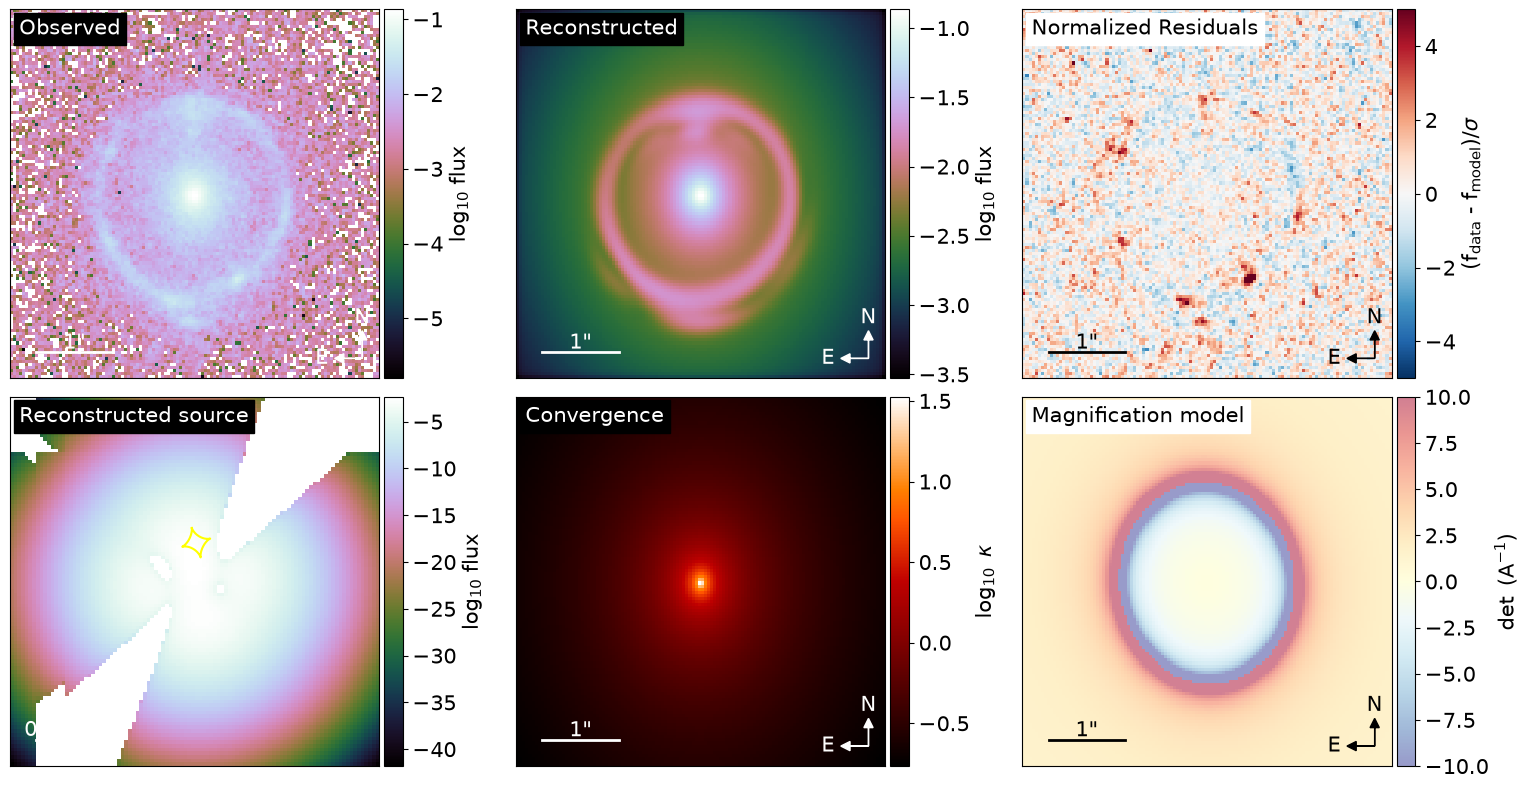

In [7]:
fig = output.plot_model_overview(lens_name="lens_system2", model_id="example")

We only ran a pre-sampling optimization here and did not perform a MCMC sampling. So, the above model is the optimized model that the MCMC sample can initiate from. The `kwargs_result` dictionary of the pre-sampling optimization step can be accessed through `Output.kwargs_result` after loading an output using the `Output.load_output()` method.

In [8]:
output.load_output(lens_name="lens_system2", model_id="example")

output.kwargs_result

Loaded output for lens_system2 with model ID example.
dolphin version used: 1.4.0
lenstronomy version used: 1.14.1
jaxtronomy version used: 0.1.4


{'kwargs_lens': [{'theta_E': 1.22065615023889,
   'gamma': 2.0165749992806834,
   'e1': -0.12590599611871522,
   'e2': -0.0033681588715002023,
   'center_x': 0.023116691714274436,
   'center_y': -0.040906291471282094},
  {'gamma_ext': 0.05928309230483292,
   'psi_ext': -1.3978601347813862,
   'ra_0': 0,
   'dec_0': 0}],
 'kwargs_source': [{'amp': 1,
   'n_max': 4,
   'beta': 0.10010217695312738,
   'center_x': 0.03230077306464412,
   'center_y': -0.2484886765112281}],
 'kwargs_lens_light': [{'amp': 1,
   'sigma_min': 0.008,
   'sigma_width': 2.5,
   'e1': -0.12397214293599904,
   'e2': 0.003037803011656283,
   'center_x': 0.023116691714274436,
   'center_y': -0.040906291471282094}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

When necessary, the settings of the model run---that was read out of the 'config_{lens_name}.yaml' file---can be accessed through the `output.model_settings` variable.

In [9]:
output.model_settings

{'lens_name': 'lens_system2',
 'band': ['F390W'],
 'model': {'lens': ['EPL', 'SHEAR_GAMMA_PSI'],
  'lens_light': ['MGE_SET_ELLIPSE'],
  'source_light': ['SHAPELETS']},
 'lens_options': {'centroid_init': [0.04, -0.04]},
 'lens_light_options': {'mge_config': {'0': {'n_comp': 10}},
  'fix': {'0': {'sigma_min': 0.008, 'sigma_width': 2.5}}},
 'source_light_options': {'n_max': [4]},
 'fitting': {'pso': True,
  'pso_settings': {'num_particle': 20, 'num_iteration': 50},
  'sampling': True,
  'sampler': 'emcee',
  'sampler_settings': {'n_burn': 0,
   'n_run': 100,
   'walkerRatio': 2,
   'threadCount': 1,
   'init_samples': None}},
 'numeric_options': {'supersampling_factor': [2]},
 'pixel_size': [array(0.04000019)]}